# Exploratory Data Analysis — Dataset Klasifikasi Sampah

## BUSINESS QUESTIONS
1. Bagaimana distribusi jumlah gambar antar kelas — apakah dataset seimbang atau terdapat class imbalance?
2. Bagaimana variasi ukuran gambar (width × height) dalam dataset — apakah perlu standarisasi resolusi sebelum pelatihan model?
3. Bagaimana distribusi ukuran file (KB) antar gambar — apakah ada gambar yang terlalu besar atau terlalu kecil?
4. Bagaimana representasi visual tiap kelas sampah — apakah gambar cukup beragam dan representatif?

## IMPORT LIBRARY

In [1]:
pip install Pillow pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

## KONFIGURASI GLOBAL

In [3]:
DATASET_DIR = Path("dataset")

CLASSES = [
    "hazardous",
    "Kaca",
    "Kardus",
    "Kertas",
    "Logam",
    "organic",
    "Plastik",
    "recyclable",
    "Residu"
]

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp"]

## PENGUMPULAN INFORMASI GAMBAR

In [4]:
def collect_image_info():
    data = []

    for cls in CLASSES:
        folder_path = DATASET_DIR / cls

        if not folder_path.exists():
            print(f"Folder tidak ditemukan: {cls}")
            continue

        for img_path in folder_path.iterdir():
            if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTENSIONS:
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        mode = img.mode

                    data.append({
                        "class": cls,
                        "filename": img_path.name,
                        "extension": img_path.suffix.lower(),
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "file_size_kb": round(img_path.stat().st_size / 1024, 2)
                    })

                except Exception as e:
                    print(f"Gagal membaca gambar: {img_path} | {e}")

    return pd.DataFrame(data)


df = collect_image_info()
df

,class,filename,extension,width,height,mode,file_size_kb
0,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,13.84
1,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,13.83
2,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,12.78
3,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,14.76
4,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,15.88
...,...,...,...,...,...,...,...
1998,Residu,residu_residu_sampah-popok-bayi-sekali-pakai-c...,.jpg,224,224,RGB,25.32
1999,Residu,residu_residu_Sampah-Popok-yang-berhasil-dikum...,.jpg,224,224,RGB,24.41
2000,Residu,residu_residu_tips-memilih-pembalut-yang-aman-...,.jpg,224,224,RGB,18.57
2001,Residu,residu_residu_tumpukan_popok_di_jembatan_dinoy...,.jpg,224,224,RGB,39.43


## BASIC INFORMATION

In [5]:
def show_basic_info(df):
    print("\n=== BASIC INFORMATION ===")
    print(f"Total gambar: {len(df)}")
    print(f"Total kelas: {df['class'].nunique()}")

    print("\nJumlah gambar per kelas:")
    print(df["class"].value_counts())

    print("\nInformasi ukuran gambar:")
    print(df[["width", "height", "file_size_kb"]].describe())

    print("\nFormat file:")
    print(df["extension"].value_counts())

    print("\nMode warna:")
    print(df["mode"].value_counts())


show_basic_info(df)


=== BASIC INFORMATION ===
Total gambar: 2003
Total kelas: 9

Jumlah gambar per kelas:
class
Kaca          452
Plastik       283
hazardous     255
organic       232
recyclable    211
Residu        205
Kardus        167
Kertas         99
Logam          99
Name: count, dtype: int64

Informasi ukuran gambar:
        width  height  file_size_kb
count  2003.0  2003.0   2003.000000
mean    224.0   224.0     17.113420
std       0.0     0.0      7.794254
min     224.0   224.0      3.420000
25%     224.0   224.0     11.655000
50%     224.0   224.0     15.390000
75%     224.0   224.0     21.215000
max     224.0   224.0     42.540000

Format file:
extension
.jpg    2003
Name: count, dtype: int64

Mode warna:
mode
RGB    2003
Name: count, dtype: int64


## VISUALISASI EDA

### Distribusi Jumlah Gambar per Kelas

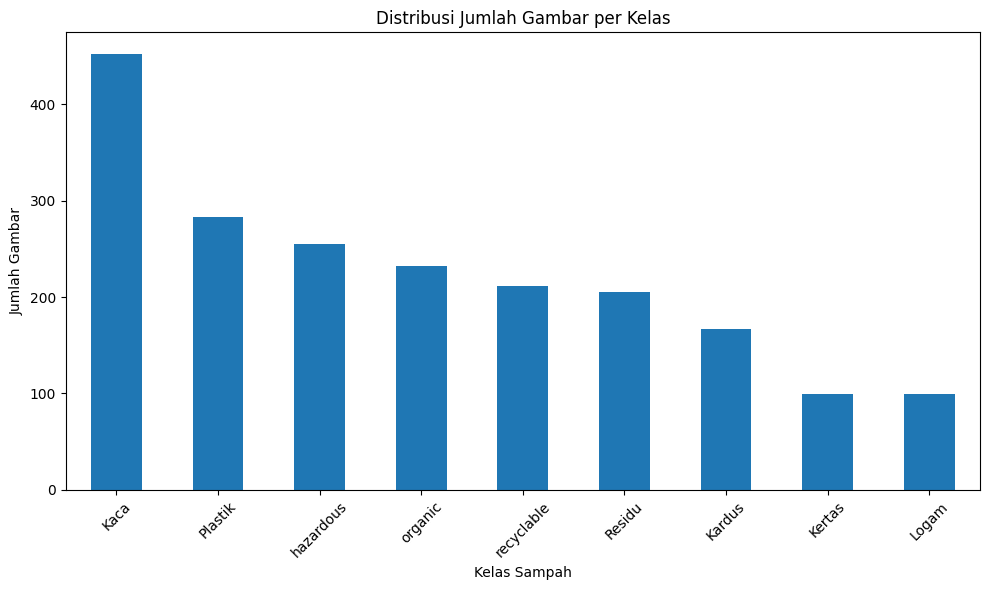

In [6]:
def plot_class_distribution(df):
    class_counts = df["class"].value_counts()

    plt.figure(figsize=(10, 6))
    class_counts.plot(kind="bar")
    plt.title("Distribusi Jumlah Gambar per Kelas")
    plt.xlabel("Kelas Sampah")
    plt.ylabel("Jumlah Gambar")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("eda_class_distribution.png")
    plt.show()


plot_class_distribution(df)

- kelas dengan jumlah gambar yang jauh lebih sedikit dari kelas lain berpotensi menyebabkan model bias
- perlu dilakukan augmentasi atau undersampling untuk menyeimbangkan distribusi kelas

### Distribusi Ukuran Gambar (Width × Height)

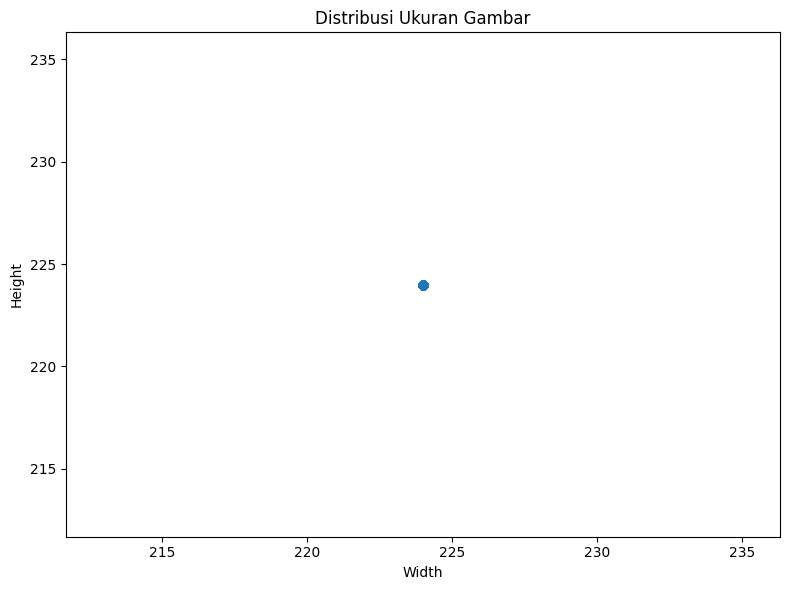

In [7]:
def plot_image_size_distribution(df):
    plt.figure(figsize=(8, 6))
    plt.scatter(df["width"], df["height"])
    plt.title("Distribusi Ukuran Gambar")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.tight_layout()
    plt.savefig("eda_image_size_distribution.png")
    plt.show()


plot_image_size_distribution(df)

- gambar yang tersebar jauh dari titik pusat menunjukkan variasi resolusi yang besar
- model klasifikasi gambar umumnya membutuhkan input dengan ukuran yang seragam (misal: 224×224 px)

### Distribusi Ukuran File Gambar (KB)

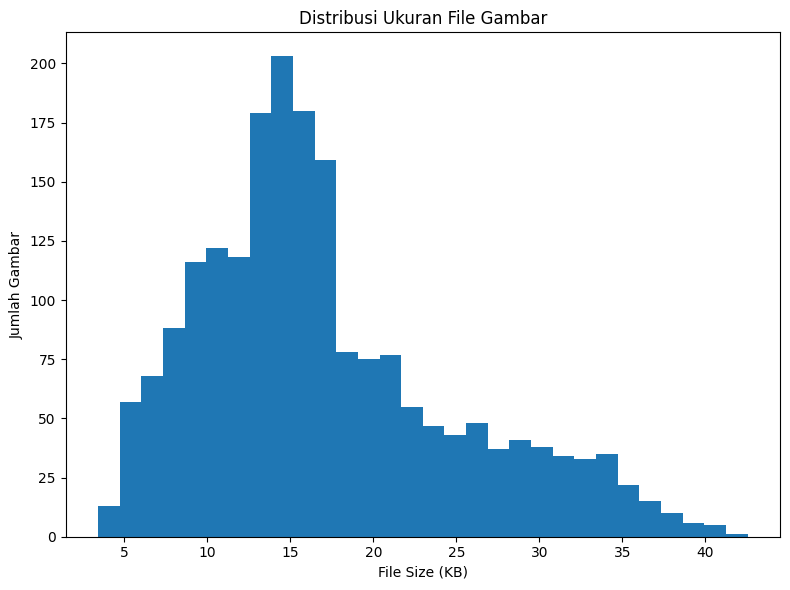

In [8]:
def plot_file_size_distribution(df):
    plt.figure(figsize=(8, 6))
    plt.hist(df["file_size_kb"], bins=30)
    plt.title("Distribusi Ukuran File Gambar")
    plt.xlabel("File Size (KB)")
    plt.ylabel("Jumlah Gambar")
    plt.tight_layout()
    plt.savefig("eda_file_size_distribution.png")
    plt.show()


plot_file_size_distribution(df)

- gambar dengan ukuran file sangat kecil (< 5 KB) kemungkinan memiliki kualitas rendah atau resolusi terlalu kecil
- gambar dengan ukuran file sangat besar dapat memperlambat proses pelatihan model

### Sample Gambar per Kelas

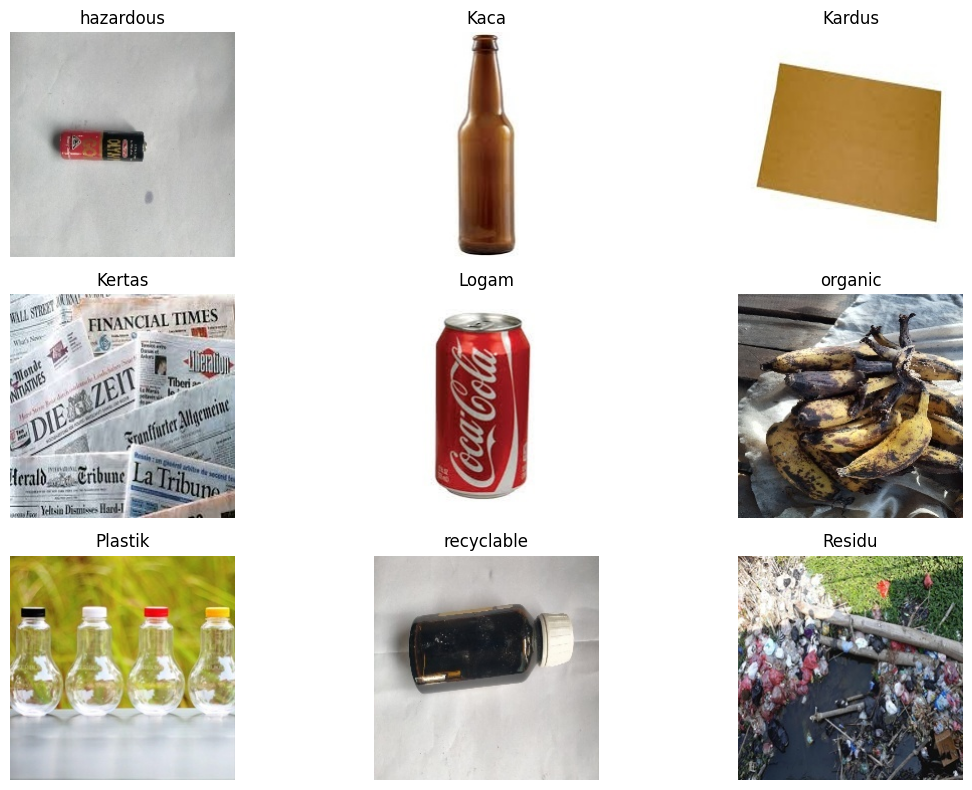

In [9]:
def plot_sample_images():
    plt.figure(figsize=(12, 8))

    index = 1

    for cls in CLASSES:
        folder_path = DATASET_DIR / cls

        if folder_path.exists():
            images = [
                img for img in folder_path.iterdir()
                if img.is_file() and img.suffix.lower() in IMAGE_EXTENSIONS
            ]

            if images:
                img_path = images[0]

                with Image.open(img_path) as img:
                    plt.subplot(3, 3, index)
                    plt.imshow(img)
                    plt.title(cls)
                    plt.axis("off")
                    index += 1

        if index > 9:
            break

    plt.tight_layout()
    plt.savefig("eda_sample_images.png")
    plt.show()


plot_sample_images()

- visualisasi sample gambar membantu memverifikasi apakah gambar sudah tersimpan di kelas yang tepat
- perhatikan apakah gambar pada tiap kelas cukup beragam untuk melatih model yang generalisasi dengan baik

## MENYIMPAN HASIL EDA

In [10]:
def save_eda_result(df):
    df.to_csv("eda_result.csv", index=False)
    print("\nHasil EDA disimpan ke eda_result.csv")
    print("Visualisasi disimpan sebagai:")
    print("- eda_class_distribution.png")
    print("- eda_image_size_distribution.png")
    print("- eda_file_size_distribution.png")
    print("- eda_sample_images.png")


save_eda_result(df)


Hasil EDA disimpan ke eda_result.csv
Visualisasi disimpan sebagai:
- eda_class_distribution.png
- eda_image_size_distribution.png
- eda_file_size_distribution.png
- eda_sample_images.png


hasil EDA dataset klasifikasi sampah telah selesai dilakukan:
- informasi dasar dataset tersimpan pada `eda_result.csv`
- visualisasi distribusi kelas, ukuran gambar, ukuran file, dan sample gambar per kelas telah disimpan
- hasil EDA ini dapat digunakan sebagai dasar pertimbangan untuk proses augmentasi data dan pemilihan arsitektur model

In [11]:
df

,class,filename,extension,width,height,mode,file_size_kb
0,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,13.84
1,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,13.83
2,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,12.78
3,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,14.76
4,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,15.88
...,...,...,...,...,...,...,...
1998,Residu,residu_residu_sampah-popok-bayi-sekali-pakai-c...,.jpg,224,224,RGB,25.32
1999,Residu,residu_residu_Sampah-Popok-yang-berhasil-dikum...,.jpg,224,224,RGB,24.41
2000,Residu,residu_residu_tips-memilih-pembalut-yang-aman-...,.jpg,224,224,RGB,18.57
2001,Residu,residu_residu_tumpukan_popok_di_jembatan_dinoy...,.jpg,224,224,RGB,39.43
